In [2]:
# 📚 Basic EDA for Predictive Maintenance Dataset

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.preprocessing import load_cmapss_dataset, add_rul

# Load the dataset
data_path = "../data/raw/train_FD001.txt"
df = load_cmapss_dataset(data_path)
df = add_rul(df)

# Show basic info
print("Shape of the dataset:", df.shape)
print("\nColumns:", df.columns)
print("\nDataset Sample:")
display(df.head())


Shape of the dataset: (20631, 27)

Columns: Index(['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2',
       'op_setting_3', 'sensor_measurement_1', 'sensor_measurement_2',
       'sensor_measurement_3', 'sensor_measurement_4', 'sensor_measurement_5',
       'sensor_measurement_6', 'sensor_measurement_7', 'sensor_measurement_8',
       'sensor_measurement_9', 'sensor_measurement_10',
       'sensor_measurement_11', 'sensor_measurement_12',
       'sensor_measurement_13', 'sensor_measurement_14',
       'sensor_measurement_15', 'sensor_measurement_16',
       'sensor_measurement_17', 'sensor_measurement_18',
       'sensor_measurement_19', 'sensor_measurement_20',
       'sensor_measurement_21', 'RUL'],
      dtype='object')

Dataset Sample:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187



Missing values per column:
unit_number              0
time_in_cycles           0
op_setting_1             0
op_setting_2             0
op_setting_3             0
sensor_measurement_1     0
sensor_measurement_2     0
sensor_measurement_3     0
sensor_measurement_4     0
sensor_measurement_5     0
sensor_measurement_6     0
sensor_measurement_7     0
sensor_measurement_8     0
sensor_measurement_9     0
sensor_measurement_10    0
sensor_measurement_11    0
sensor_measurement_12    0
sensor_measurement_13    0
sensor_measurement_14    0
sensor_measurement_15    0
sensor_measurement_16    0
sensor_measurement_17    0
sensor_measurement_18    0
sensor_measurement_19    0
sensor_measurement_20    0
sensor_measurement_21    0
RUL                      0
dtype: int64


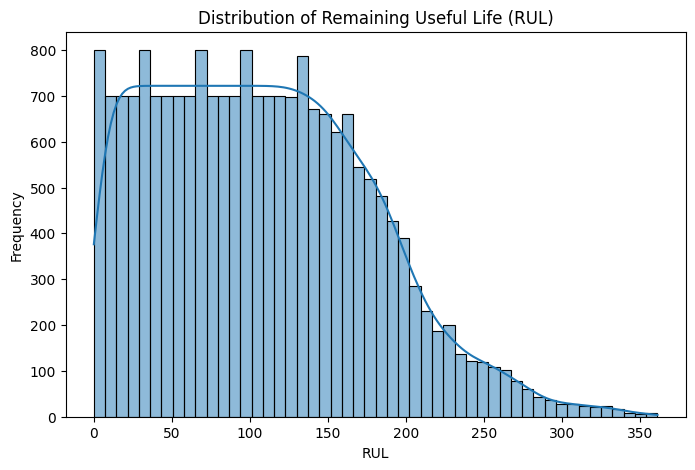

In [3]:
# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 📈 Plot distribution of RUL
plt.figure(figsize=(8,5))
sns.histplot(df['RUL'], bins=50, kde=True)
plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL')
plt.ylabel('Frequency')
plt.show()

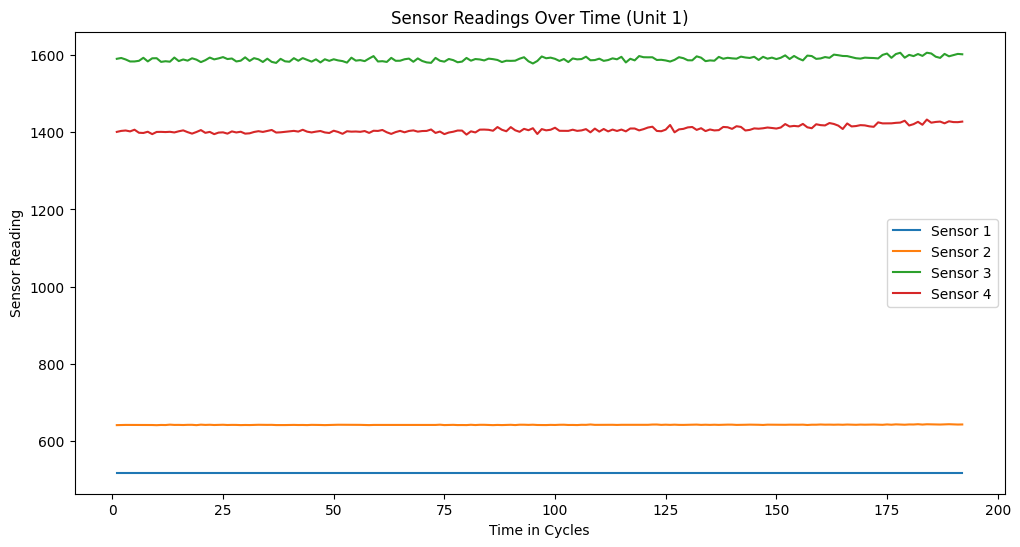

In [4]:
# 📈 Sensor Measurements over Cycles (example for sensor_measurement_1)
sample_unit = df[df['unit_number'] == 1]

plt.figure(figsize=(12,6))
for i in range(1, 5):  # Just plotting first 4 sensors for now
    plt.plot(sample_unit['time_in_cycles'], sample_unit[f'sensor_measurement_{i}'], label=f'Sensor {i}')
plt.title('Sensor Readings Over Time (Unit 1)')
plt.xlabel('Time in Cycles')
plt.ylabel('Sensor Reading')
plt.legend()
plt.show()

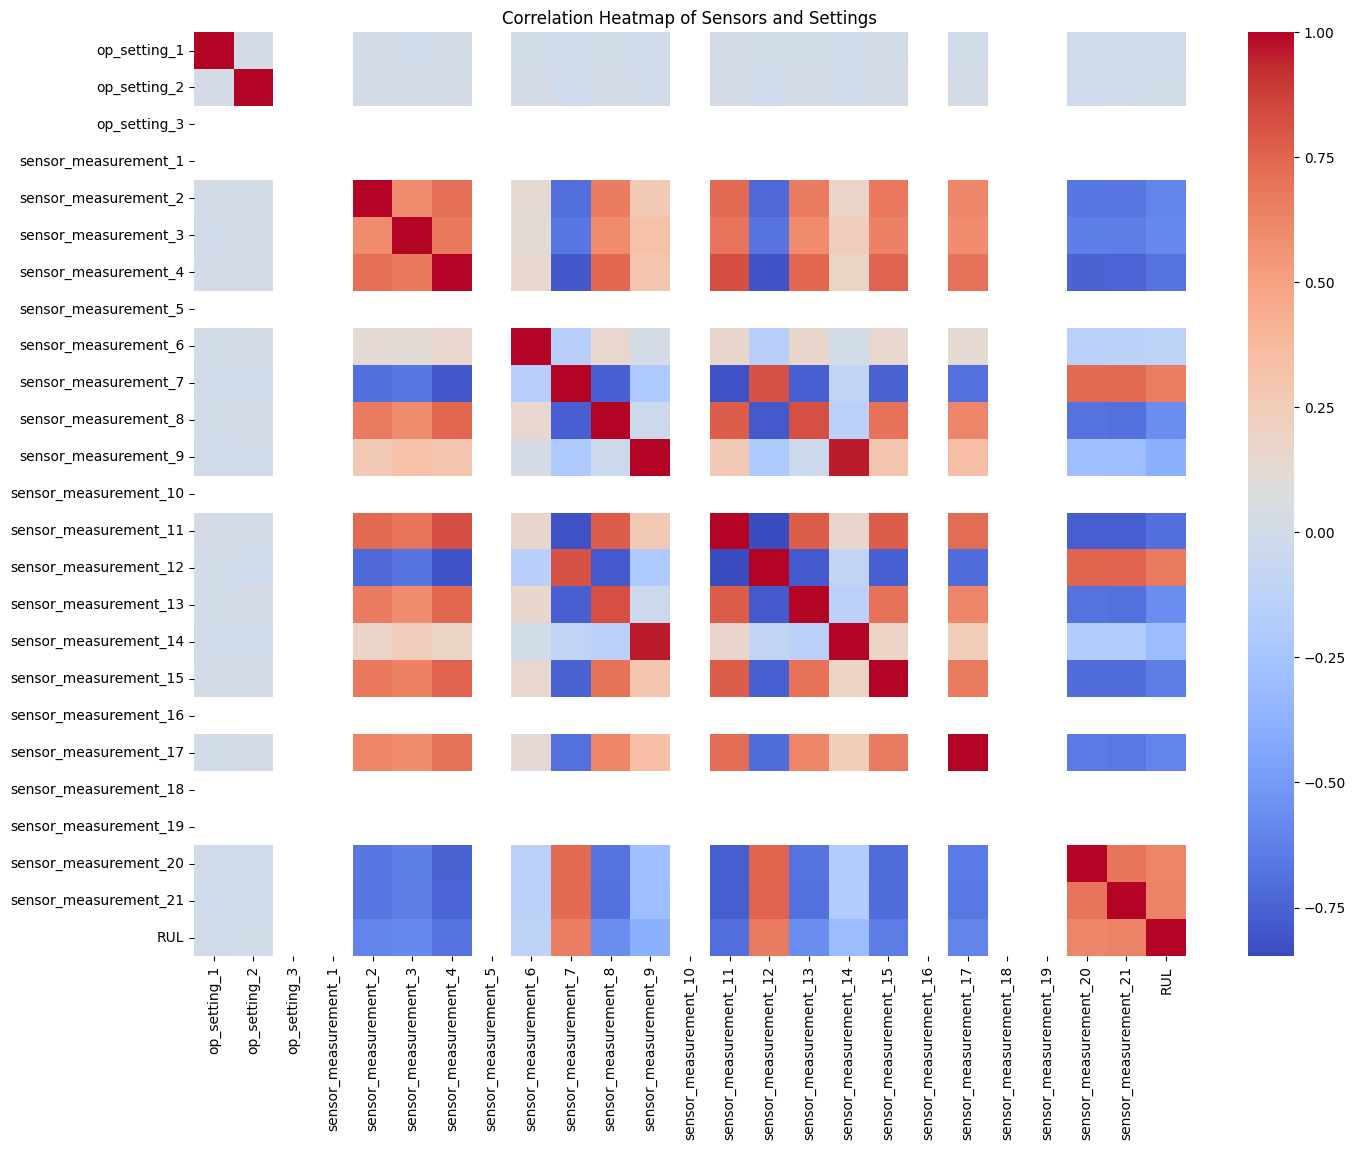

In [5]:
# 📈 Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation = df.drop(columns=['unit_number', 'time_in_cycles']).corr()
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Sensors and Settings')
plt.show()